## NB2
## Goal
RFM 
Recency (R) = How recently customer purchased
Frequency (F) = How often they purchased
Monetary (M) = Hoe much they spent

# Import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# (1) Load the cleaned dataset

In [3]:
df = pd.read_csv("C:/Projects/08_Customer_Intellignece_System/data/Cleaned_dataset.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,Invoice_Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00


## (2) Define Reference Date

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# (3) Calculate R, F, M

In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (reference_date - x.max()).days,
    'InvoiceNo' : 'nunique',
    'Total_Price' : 'sum'
})

## (4) Rename Columns

In [10]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

## (5) Inspect RFM Table

In [11]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## (6) Quick Visualization

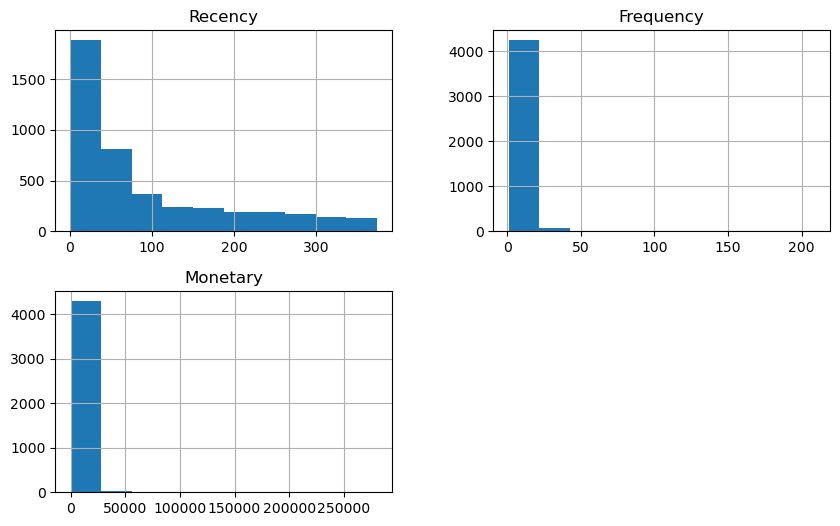

In [12]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(figsize=(10,6))
plt.show()

## (7) save RFM table

In [13]:
rfm.to_csv("C:/Projects/08_Customer_Intellignece_System/data/rfm_table.csv", index=False)

## (8) Apply Log Transformation

In [14]:
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

## (9) Check again

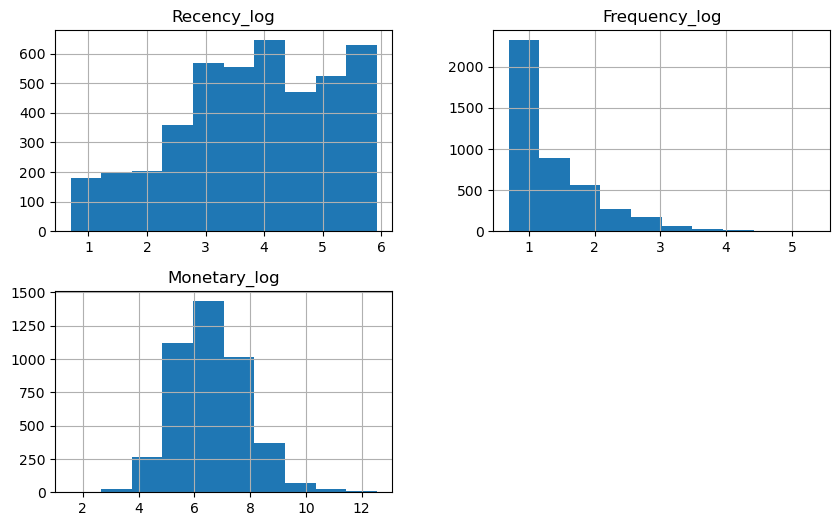

In [15]:
rfm[['Recency_log', 'Frequency_log', 'Monetary_log']].hist(figsize=(10,6))
plt.show()

# (10) Save the new csv 

In [16]:
rfm.to_csv("C:/Projects/08_Customer_Intellignece_System/data/rfm_table_final.csv")